# Football Player Evaluation Model - Full Pipeline

This notebook contains the complete pipeline for training and evaluating the football player evaluation model.

## 0. Setup - Imports and Configuration

In [1]:
import pandas as pd

import config
from src.analysis.prediction_utils import matches_info_df
from src.data.data_loader import load_statsbomb_socceraction_data
from src.data.data_splitter import split_matches
from src.ml.models.model_factory import create_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor
from src.ml.preprocessing.xthreat import get_default_xt_model
from src.ml.train import ModelTrainer

In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
data = load_statsbomb_socceraction_data("data/statsbomb/data", 55, 282)
data_list = list(data)


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

### 1.1 Split matches and display each set's match information

In [4]:
train_matches, val_matches, test_matches = split_matches(data_list, random_seed=18)

# Extract match information for each set
train_matches_df = matches_info_df(train_matches)
val_matches_df = matches_info_df(val_matches)
test_matches_df = matches_info_df(test_matches)

for name, df in [("TRAINING SET", train_matches_df), ("VALIDATION SET", val_matches_df), ("TEST SET", test_matches_df)]:
    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)
    print(f"Total matches: {len(df)}\n")
    print(df[['match_id', 'summary', 'events_count']].to_string(index=False))

Splitting 51 matches...
  → Train: 37 matches (72.5%)
  → Val: 9 matches (17.6%)
  → Test: 5 matches (9.8%)
TRAINING SET
Total matches: 37

 match_id                                                  summary  events_count
  3930178           Croatia 1 : 1 Italy (Group Stage) [24.06.2024]          4006
  3942819     Netherlands 1 : 2 England (Semi-finals) [10.07.2024]          3485
  3942226        Spain 2 : 1 Germany (Quarter-finals) [05.07.2024]          4463
  3938645         Ukraine 0 : 0 Belgium (Group Stage) [26.06.2024]          3525
  3938639          Turkey 3 : 1 Georgia (Group Stage) [18.06.2024]          3837
  3930166 Portugal 2 : 1 Czech Republic (Group Stage) [18.06.2024]          3602
  3930183        Slovakia 1 : 1 Romania (Group Stage) [26.06.2024]          2886
  3938644        Georgia 2 : 0 Portugal (Group Stage) [26.06.2024]          3659
  3930181        England 0 : 0 Slovenia (Group Stage) [25.06.2024]          3688
  3930175         Belgium 2 : 0 Romania (Group Sta

### 1.2 Pie chart - matches distribution across sets

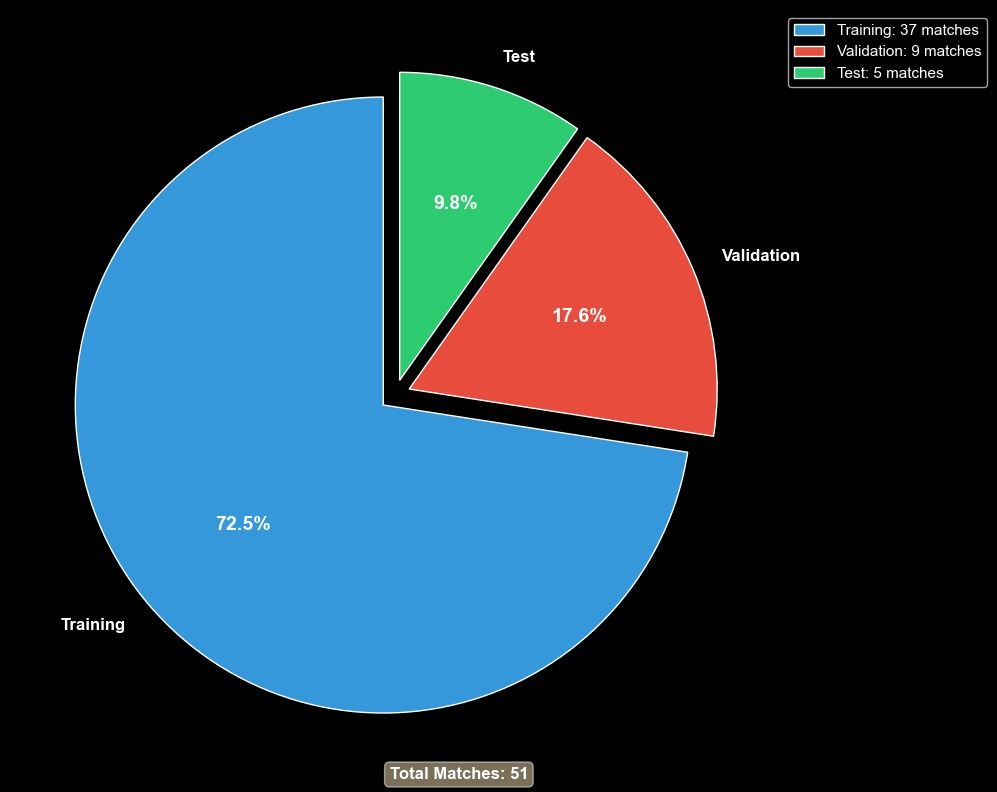

In [5]:
import matplotlib.pyplot as plt

sets = ['Training', 'Validation', 'Test']
counts = [len(train_matches_df), len(val_matches_df), len(test_matches_df)]
colors = ['#3498db', '#e74c3c', '#2ecc71']
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=sets,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

legend_labels = [f'{set_name}: {count} matches' for set_name, count in zip(sets, counts)]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

total_matches = sum(counts)
fig.text(0.5, 0.02, f'Total Matches: {total_matches}',
         ha='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'models/matches_distribution.png', dpi=300, bbox_inches='tight')


## 2. Preprocessing Data


#### Initialize preprocessor with sequence length and xT model

In [6]:
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

#### Process training, validation, and test sets

In [7]:
X_train, y_train, p_train, m_train = preprocessor.process_matches(train_matches)
X_val, y_val, p_val, m_val = preprocessor.process_matches(val_matches)
X_test, y_test, p_test, m_test = preprocessor.process_matches(test_matches)

→Processing match 3930178: 4006 events (mode: training)
 → Generated 1549 sequences, 1549 labels for match 3930178
→Processing match 3942819: 3485 events (mode: training)
 → Generated 1510 sequences, 1510 labels for match 3942819
→Processing match 3942226: 4463 events (mode: training)
 → Generated 1522 sequences, 1522 labels for match 3942226
→Processing match 3938645: 3525 events (mode: training)
 → Generated 1191 sequences, 1191 labels for match 3938645
→Processing match 3938639: 3837 events (mode: training)
 → Generated 1440 sequences, 1440 labels for match 3938639
→Processing match 3930166: 3602 events (mode: training)
 → Generated 1289 sequences, 1289 labels for match 3930166
→Processing match 3930183: 2886 events (mode: training)
 → Generated 895 sequences, 895 labels for match 3930183
→Processing match 3938644: 3659 events (mode: training)
 → Generated 1413 sequences, 1413 labels for match 3938644
→Processing match 3930181: 3688 events (mode: training)
 → Generated 1484 sequence

#### Display dataset sizes

In [8]:
print(f"Train set: {X_train.shape[0]} sequences with shape {X_train.shape}")
print(f"Val set: {X_val.shape[0]} sequences with shape {X_val.shape}")
print(f"Test set: {X_test.shape[0]} sequences with shape {X_test.shape}")

Train set: 48718 sequences with shape (48718, 8, 46)
Val set: 13024 sequences with shape (13024, 8, 46)
Test set: 6378 sequences with shape (6378, 8, 46)


## 3. Build Model

In [9]:
MODEL_TYPE = 'transformer'  # Options: 'lstm', 'attention_lstm', 'transformer'
model = create_model(
    MODEL_TYPE,
    input_shape=(config.SEQUENCE_LENGTH, X_train.shape[2])
)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 8, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 8, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8, 128)    │      6,016 │ masking[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 8)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (None, 8, 128)    │      1,024 │ dense[0][0],      │
│ (AddPositionalEnco… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 8, 128),  │     66,048 │ add_positional_e… │
│ (MultiHeadAttentio… │ (None, 8)]        │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 128)    │          0 │ add_positional_e… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8, 512)    │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8, 128)    │     65,664 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 128)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 8)         │          0 │ any[0][0],        │
│ (LogicalOr)         │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 8)         │          0 │ logical_or[0][0], │
│ (LogicalOr)         │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 8, 128),  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │ (None, 8)]        │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 411,905 (1.57 MB)

 Trainable params: 411,905 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

#### Initialize trainer and train the model

Note: Training may stop before reaching max epochs due to EarlyStopping callback.
If val_loss doesn't improve for EARLY_STOPPING_PATIENCE epochs (default: 20), training stops.
This prevents overfitting when model stops generalizing to validation set.

In [10]:
trainer = ModelTrainer(model, f"models/{MODEL_TYPE}/")
trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/2
1522/1523 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - attention_weights_loss: 0.0163 - loss: 0.0772 - value_loss: 0.0772 - value_mae: 0.0619
Epoch 1: val_loss improved from None to 0.00094, saving model to models/transformer/best_model.keras
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - attention_weights_loss: 0.0165 - loss: 0.0129 - value_loss: 0.0129 - value_mae: 0.0247 - val_attention_weights_loss: 0.0183 - val_loss: 9.3536e-04 - val_value_loss: 9.3536e-04 - val_value_mae: 0.0120 - learning_rate: 0.0010
Epoch 2/2
1521/1523 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - attention_weights_loss: 0.0196 - loss: 0.0013 - value_loss: 0.0013 - value_mae: 0.0147
Epoch 2: val_loss improved from 0.00094 to 0.00074, saving model to models/transformer/best_model.keras
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - attention_weights_loss: 0.0204 - loss: 0.0012 - value_loss: 0.0012 - value_mae: 0.0143 - val_attention_weights_loss: 0.0227 - val_loss: 7.3739e-04 - val_value_loss: 7.3739e-04 - val_value_mae

## 5. Evaluate Model

#### 5.1 Evaluate on validation set

In [11]:
from rich import print

val_metrics = trainer.evaluate(X_val, y_val)
print(val_metrics)

407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


{'loss': 0.0007373897824436426, 'mae': 0.0007373897824436426, 'rmse': 0.027154916569194727}

#### 5.2 Evaluate on test set

In [12]:
from rich import print

test_metrics = trainer.evaluate(X_test, y_test)
print(test_metrics)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


{'loss': 0.0010906829265877604, 'mae': 0.0010870497208088636, 'rmse': 0.03302549003484576}

## 6. Summary and Results

In [13]:
history_dict = trainer.history.history
print(history_dict.keys())

dict_keys(['attention_weights_loss', 'loss', 'val_attention_weights_loss', 'val_loss', 'val_value_loss', 
'val_value_mae', 'value_loss', 'value_mae', 'learning_rate'])

#### Save training metrics and plots

Metrics saved to models/transformer/metrics.json


Pipeline completed successfully!

Best model saved as: models/transformer/best_model.keras

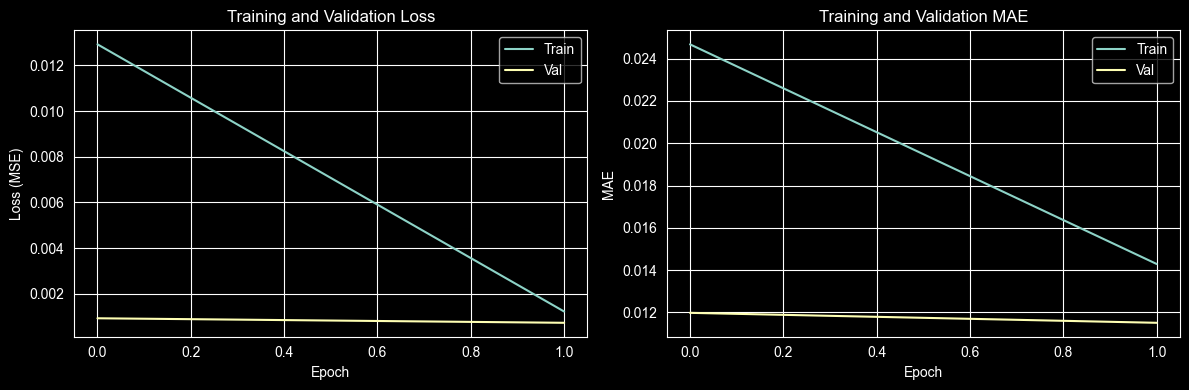

In [14]:
all_metrics = {
    'validation': val_metrics,
    'test': test_metrics
}

trainer.save_training_metrics(all_metrics)
trainer.plot_training_history(filename="training_history.png")

print("Pipeline completed successfully!")
print(f"Best model saved as: models/{MODEL_TYPE}/best_model.keras")

## 7. Analysis

#### Extract match information from validation set

In [15]:
val_matches_df = matches_info_df(val_matches)
val_matches_df

,match_id,summary,events_count
0,3942752,Spain 2 : 1 France (Semi-finals) [09.07.2024],3328
1,3930184,Czech Republic 1 : 2 Turkey (Group Stage) [26.06.2024],2953
2,3942349,Portugal 0 : 0 France (Quarter-finals) [05.07.2024],5190
3,3941019,France 1 : 0 Belgium (Round of 16) [01.07.2024],3941
4,3930163,Serbia 0 : 1 England (Group Stage) [16.06.2024],3920
5,3941020,Portugal 0 : 0 Slovenia (Round of 16) [01.07.2024],4221
6,3930167,Croatia 2 : 2 Albania (Group Stage) [19.06.2024],3721
7,3942382,Netherlands 2 : 1 Turkey (Quarter-finals) [06.07.2024],3415
8,3930173,Netherlands 0 : 0 France (Group Stage) [21.06.2024],3681


#### Summary statistics

In [16]:
print(f"\nValidation Set Summary:")
print(f"Total matches: {len(val_matches_df)}")
print(f"Total events: {val_matches_df['events_count'].sum()}")
print(f"Average events per match: {val_matches_df['events_count'].mean():.2f}")


Validation Set Summary:

Total matches: 9

Total events: 34370

Average events per match: 3818.89